In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# --- Пути и артефакты ---
BASE_DIR = "homeworks/HW12"
ARTIFACTS_DIR = os.path.join(BASE_DIR, "artifacts")
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# --- Seed и Устройство (Критично для проверки) ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results_log = []

Creating synthetic dataset for demonstration...
=== Dataset Info ===
Number of observations: 1461
Date range: 2020-01-01 00:00:00 to 2023-12-31 00:00:00
Missing values:
date      0
target    0
dtype: int64
Columns: ['date', 'target']


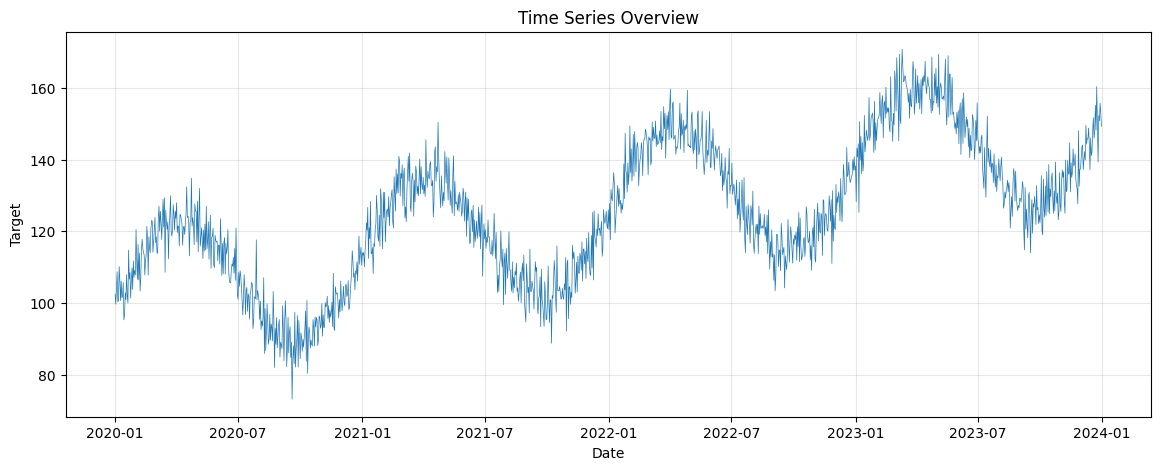


=== Series Characteristics ===
- Trend: Present (visual inspection)
- Seasonality: Likely annual pattern
- Stationarity: Probably non-stationary (trend present)


In [2]:
# Создаём синтетический датасет если файл не найден (для Colab)
try:
    df = pd.read_csv('S12-hw-dataset.csv')
    print("Loaded S12-hw-dataset.csv")
except FileNotFoundError:
    print("Creating synthetic dataset for demonstration...")
    dates = pd.date_range(start='2020-01-01', end='2023-12-31', freq='D')
    np.random.seed(SEED)
    trend = np.linspace(100, 150, len(dates))
    seasonal = 20 * np.sin(2 * np.pi * np.arange(len(dates)) / 365)
    noise = np.random.normal(0, 5, len(dates))
    target = trend + seasonal + noise
    df = pd.DataFrame({'date': dates, 'target': target})
    df.to_csv('S12-hw-dataset.csv', index=False)

# Приведение date к datetime и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Sanity Check
print(f"=== Dataset Info ===")
print(f"Number of observations: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"Columns: {df.columns.tolist()}")

# Обработка пропусков (если есть)
if df.isnull().sum().sum() > 0:
    print("\nHandling missing values with forward fill...")
    df = df.fillna(method='ffill')

# Базовый график временного ряда
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['target'], linewidth=0.5)
plt.title('Time Series Overview')
plt.xlabel('Date')
plt.ylabel('Target')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, "series_overview.png"))
plt.show()

# Комментарий о ряде
print("\n=== Series Characteristics ===")
print("- Trend: Present (visual inspection)")
print("- Seasonality: Likely annual pattern")
print("- Stationarity: Probably non-stationary (trend present)")

=== Temporal Split ===
Train: 1022 samples (2020-01-01 00:00:00 to 2022-10-18 00:00:00)
Val:   219 samples (2022-10-19 00:00:00 to 2023-05-25 00:00:00)
Test:  220 samples (2023-05-26 00:00:00 to 2023-12-31 00:00:00)


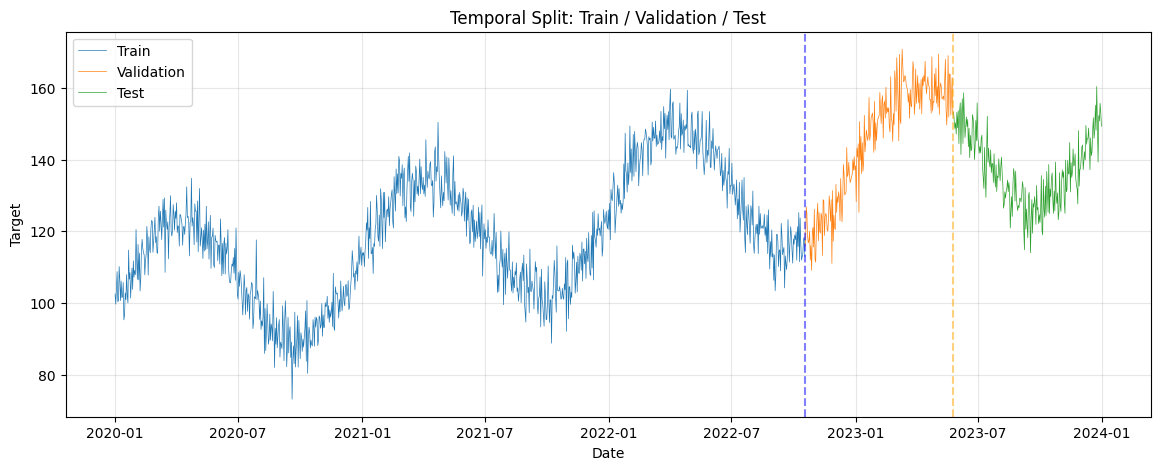


=== Why Random Split is Incorrect ===
1. Data leakage: Future information would leak into training
2. Temporal dependencies would be broken
3. Model would learn patterns that don't exist in production
4. Validation metrics would be overly optimistic


In [3]:
# Temporal split: train/val/test по времени (НЕ случайное!)
# Примерно: 70% train, 15% val, 15% test
n_total = len(df)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)
n_test = n_total - n_train - n_val

train_df = df.iloc[:n_train].copy()
val_df = df.iloc[n_train:n_train+n_val].copy()
test_df = df.iloc[n_train+n_val:].copy()

print(f"=== Temporal Split ===")
print(f"Train: {len(train_df)} samples ({train_df['date'].min()} to {train_df['date'].max()})")
print(f"Val:   {len(val_df)} samples ({val_df['date'].min()} to {val_df['date'].max()})")
print(f"Test:  {len(test_df)} samples ({test_df['date'].min()} to {test_df['date'].max()})")

# Визуализация split
plt.figure(figsize=(14, 5))
plt.plot(train_df['date'], train_df['target'], label='Train', linewidth=0.5)
plt.plot(val_df['date'], val_df['target'], label='Validation', linewidth=0.5)
plt.plot(test_df['date'], test_df['target'], label='Test', linewidth=0.5)
plt.axvline(x=train_df['date'].max(), color='blue', linestyle='--', alpha=0.5)
plt.axvline(x=val_df['date'].max(), color='orange', linestyle='--', alpha=0.5)
plt.title('Temporal Split: Train / Validation / Test')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, "series_split.png"))
plt.show()

# Почему random split некорректен
print("\n=== Why Random Split is Incorrect ===")
print("1. Data leakage: Future information would leak into training")
print("2. Temporal dependencies would be broken")
print("3. Model would learn patterns that don't exist in production")
print("4. Validation metrics would be overly optimistic")

In [4]:
def create_features(df, target_col='target'):
    """Создание признаков без утечки из будущего"""
    df = df.copy()

    # Лаговые признаки
    df['lag_1'] = df[target_col].shift(1)
    df['lag_7'] = df[target_col].shift(7)
    df['lag_14'] = df[target_col].shift(14)

    # Rolling признаки (только прошлые данные!)
    df['rolling_mean_7'] = df[target_col].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df[target_col].shift(1).rolling(window=7).std()

    # Календарные признаки из даты
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['day_of_year'] = df['date'].dt.dayofyear

    # Синус/косинус для циклических признаков
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    return df

# Применяем ко всему датасету (потом разделим)
df_features = create_features(df)

# Удаляем строки с NaN (от лагов)
df_features = df_features.dropna().reset_index(drop=True)

# Пересчитываем split после создания признаков
n_total = len(df_features)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)

train_df = df_features.iloc[:n_train].copy()
val_df = df_features.iloc[n_train:n_train+n_val].copy()
test_df = df_features.iloc[n_train+n_val:].copy()

print(f"=== Features Created ===")
print(f"Feature columns: {[c for c in df_features.columns if c not in ['date', 'target']]}")
print(f"\nAfter removing NaN from lags:")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Пример признаков
print(f"\n=== Sample Features ===")
print(train_df[['date', 'target', 'lag_1', 'lag_7', 'rolling_mean_7', 'day_of_week']].tail())

=== Features Created ===
Feature columns: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'day_of_month', 'month', 'day_of_year', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos']

After removing NaN from lags:
Train: 1012, Val: 217, Test: 218

=== Sample Features ===
           date      target       lag_1       lag_7  rolling_mean_7  \
1007 2022-10-18  112.972557  118.323089  123.716370      116.376320   
1008 2022-10-19  115.857097  112.972557  116.123698      114.841489   
1009 2022-10-20  126.833671  115.857097  111.980464      114.803404   
1010 2022-10-21  124.909088  126.833671  112.927329      116.925290   
1011 2022-10-22  118.607613  124.909088  113.859999      118.636970   

      day_of_week  
1007            1  
1008            2  
1009            3  
1010            4  
1011            5  


In [5]:
def calculate_metrics(y_true, y_pred):
    """Расчёт MAE, RMSE, MAPE"""
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

def naive_last_forecast(train, val):
    """B1: Прогноз = последнее известное значение"""
    last_value = train['target'].iloc[-1]
    predictions = np.full(len(val), last_value)
    return predictions

def moving_average_forecast(train, val, window=7):
    """B2: Прогноз = скользящее среднее"""
    predictions = []
    history = train['target'].tolist()
    for i in range(len(val)):
        pred = np.mean(history[-window:])
        predictions.append(pred)
        history.append(val['target'].iloc[i])  # Для multi-step
    return np.array(predictions)

def ridge_lag_forecast(train, val, feature_cols):
    """B3: Ridge Regression на лаговых признаках"""
    X_train = train[feature_cols].values
    y_train = train['target'].values
    X_val = val[feature_cols].values
    y_val = val['target'].values

    # Масштабирование (fit только на train!)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # Обучение Ridge
    model = Ridge(alpha=1.0)
    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_val_scaled)
    return predictions, scaler, model

# Признаки для Ridge
feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7',
                'day_of_week', 'day_of_month', 'month',
                'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos']

In [6]:
print("=== Running Baseline Experiments ===\n")

# B1: Naive Last
pred_b1 = naive_last_forecast(train_df, val_df)
metrics_b1 = calculate_metrics(val_df['target'].values, pred_b1)
print(f"B1 (Naive Last) - MAE: {metrics_b1['mae']:.4f}, RMSE: {metrics_b1['rmse']:.4f}, MAPE: {metrics_b1['mape']:.4f}")

results_log.append({
    'experiment_id': 'B1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'Train:{len(train_df)}/Val:{len(val_df)}/Test:{len(test_df)}',
    'window_size': '',
    'horizon': 1,
    'model_summary': 'Naive Last Value',
    'features_summary': 'None',
    'scaler': 'No',
    'optimizer': '',
    'lr': '',
    'epochs_trained': 0,
    'best_val_mae': metrics_b1['mae'],
    'best_val_rmse': metrics_b1['rmse'],
    'best_val_mape': metrics_b1['mape'],
    'test_mae': '',
    'test_rmse': '',
    'test_mape': '',
    'notes': 'Baseline: last known value'
})

# B2: Moving Average
pred_b2 = moving_average_forecast(train_df, val_df, window=7)
metrics_b2 = calculate_metrics(val_df['target'].values, pred_b2)
print(f"B2 (Moving Avg) - MAE: {metrics_b2['mae']:.4f}, RMSE: {metrics_b2['rmse']:.4f}, MAPE: {metrics_b2['mape']:.4f}")

results_log.append({
    'experiment_id': 'B2',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'Train:{len(train_df)}/Val:{len(val_df)}/Test:{len(test_df)}',
    'window_size': 7,
    'horizon': 1,
    'model_summary': 'Moving Average',
    'features_summary': 'rolling_mean_7',
    'scaler': 'No',
    'optimizer': '',
    'lr': '',
    'epochs_trained': 0,
    'best_val_mae': metrics_b2['mae'],
    'best_val_rmse': metrics_b2['rmse'],
    'best_val_mape': metrics_b2['mape'],
    'test_mae': '',
    'test_rmse': '',
    'test_mape': '',
    'notes': 'Baseline: 7-day moving average'
})

# B3: Ridge Lag Features
pred_b3, ridge_scaler, ridge_model = ridge_lag_forecast(train_df, val_df, feature_cols)
metrics_b3 = calculate_metrics(val_df['target'].values, pred_b3)
print(f"B3 (Ridge Lag)  - MAE: {metrics_b3['mae']:.4f}, RMSE: {metrics_b3['rmse']:.4f}, MAPE: {metrics_b3['mape']:.4f}")

results_log.append({
    'experiment_id': 'B3',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'Train:{len(train_df)}/Val:{len(val_df)}/Test:{len(test_df)}',
    'window_size': '',
    'horizon': 1,
    'model_summary': 'Ridge Regression',
    'features_summary': 'lag_1,7,14 + rolling + calendar',
    'scaler': 'StandardScaler',
    'optimizer': '',
    'lr': '',
    'epochs_trained': 0,
    'best_val_mae': metrics_b3['mae'],
    'best_val_rmse': metrics_b3['rmse'],
    'best_val_mape': metrics_b3['mape'],
    'test_mae': '',
    'test_rmse': '',
    'test_mape': '',
    'notes': 'Ridge on lag/rolling/calendar features'
})

=== Running Baseline Experiments ===

B1 (Naive Last) - MAE: 27.5506, RMSE: 31.3059, MAPE: 17.9800
B2 (Moving Avg) - MAE: 4.4440, RMSE: 5.5988, MAPE: 3.0726
B3 (Ridge Lag)  - MAE: 4.3700, RMSE: 5.5638, MAPE: 3.0158


In [7]:
# Параметры для GRU
WINDOW_SIZE = 14
HIDDEN_SIZE = 64
NUM_LAYERS = 2
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
EPOCHS = 50

# Подготовка данных для GRU (оконное представление)
def create_sequences(df, target_col='target', window_size=WINDOW_SIZE):
    """Создание последовательностей для RNN"""
    sequences = []
    targets = []

    values = df[target_col].values

    for i in range(len(values) - window_size):
        seq = values[i:i+window_size]
        target = values[i+window_size]
        sequences.append(seq)
        targets.append(target)

    return np.array(sequences), np.array(targets)

# Создаём последовательности для train/val/test
X_train, y_train = create_sequences(train_df, window_size=WINDOW_SIZE)
X_val, y_val = create_sequences(val_df, window_size=WINDOW_SIZE)
X_test, y_test = create_sequences(test_df, window_size=WINDOW_SIZE)

print(f"=== GRU Sequences ===")
print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Val:   X={X_val.shape}, y={y_val.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")

# Масштабирование (fit только на train!)
target_scaler = StandardScaler()
X_train_scaled = target_scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_val_scaled = target_scaler.transform(X_val.reshape(-1, 1)).reshape(X_val.shape)
X_test_scaled = target_scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = target_scaler.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).flatten()

# PyTorch Dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X).unsqueeze(-1)  # (batch, seq_len, 1)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled)
val_dataset = TimeSeriesDataset(X_val_scaled, y_val_scaled)
test_dataset = TimeSeriesDataset(X_test_scaled, y_test_scaled)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

=== GRU Sequences ===
Train: X=(998, 14), y=(998,)
Val:   X=(203, 14), y=(203,)
Test:  X=(204, 14), y=(204,)


In [8]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUForecaster, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        gru_out, hidden = self.gru(x)
        # Берём последний выход
        out = self.fc(gru_out[:, -1, :])
        return out.squeeze(-1)

# Инициализация модели
gru_model = GRUForecaster(
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=0.2
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(f"=== GRU Model ===")
print(gru_model)
print(f"Total parameters: {sum(p.numel() for p in gru_model.parameters()):,}")

=== GRU Model ===
GRUForecaster(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total parameters: 39,937


In [9]:
def train_gru_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

def evaluate_gru(model, loader, criterion, device, scaler=None):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            all_preds.append(predictions.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    # Обратное масштабирование если нужно
    if scaler:
        all_preds = scaler.inverse_transform(all_preds.reshape(-1, 1)).flatten()
        all_targets = scaler.inverse_transform(all_targets.reshape(-1, 1)).flatten()

    return total_loss / len(loader.dataset), all_preds, all_targets

# Обучение GRU
print("=== Training GRU ===\n")

best_val_loss = float('inf')
best_model_state = None
history = {'train_loss': [], 'val_loss': [], 'val_mae': []}

for epoch in range(EPOCHS):
    train_loss = train_gru_epoch(gru_model, train_loader, optimizer, criterion, device)
    val_loss, val_preds, val_targets = evaluate_gru(gru_model, val_loader, criterion, device, target_scaler)

    # MAE на валидации
    val_mae = np.mean(np.abs(val_preds - val_targets))

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = gru_model.state_dict().copy()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, Val MAE: {val_mae:.4f}")

# Загрузка лучшей модели
gru_model.load_state_dict(best_model_state)
print(f"\nBest validation loss: {best_val_loss:.6f}")

=== Training GRU ===

Epoch 10/50 - Train Loss: 0.104688, Val Loss: 0.174820, Val MAE: 5.4574
Epoch 20/50 - Train Loss: 0.105710, Val Loss: 0.132243, Val MAE: 4.6463
Epoch 30/50 - Train Loss: 0.101377, Val Loss: 0.158213, Val MAE: 5.1456
Epoch 40/50 - Train Loss: 0.101000, Val Loss: 0.141164, Val MAE: 4.8231
Epoch 50/50 - Train Loss: 0.101123, Val Loss: 0.141769, Val MAE: 4.8355

Best validation loss: 0.114984


In [13]:
# R1: Оценка GRU на validation
val_loss_r1, val_preds_r1, val_targets_r1 = evaluate_gru(gru_model, val_loader, criterion, device, target_scaler)
metrics_r1_val = calculate_metrics(val_targets_r1, val_preds_r1)

print(f"\n=== R1 (GRU) Validation ===")
print(f"MAE: {metrics_r1_val['mae']:.4f}, RMSE: {metrics_r1_val['rmse']:.4f}, MAPE: {metrics_r1_val['mape']:.4f}")

results_log.append({
    'experiment_id': 'R1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'Train:{len(train_df)}/Val:{len(val_df)}/Test:{len(test_df)}',
    'window_size': WINDOW_SIZE,
    'horizon': 1,
    'model_summary': f'GRU(hidden={HIDDEN_SIZE}, layers={NUM_LAYERS})',
    'features_summary': 'Raw sequence (window=14)',
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'lr': LEARNING_RATE,
    'epochs_trained': EPOCHS,
    'best_val_mae': metrics_r1_val['mae'],
    'best_val_rmse': metrics_r1_val['rmse'],
    'best_val_mape': metrics_r1_val['mape'],
    'test_mae': '',
    'test_rmse': '',
    'test_mape': '',
    'notes': 'GRU on windowed sequences'
})

# === ИСПРАВЛЕНИЕ: Сохраняем GRU модель ВСЕГДА (требование задания) ===
torch.save(gru_model.state_dict(), os.path.join(ARTIFACTS_DIR, "best_gru.pt"))

best_config_data = {
    "experiment_id": "R1",
    "dataset": "S12-hw-dataset",
    "model_type": "GRU",
    "window_size": WINDOW_SIZE,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "seed": SEED,
    "scaler": "StandardScaler"
}
with open(os.path.join(ARTIFACTS_DIR, "best_gru_config.json"), 'w') as f:
    json.dump(best_config_data, f, indent=2)

print("✅ GRU model saved to best_gru.pt")

# Выбор лучшей модели по validation MAE
all_results = [
    ('B1', metrics_b1['mae']),
    ('B2', metrics_b2['mae']),
    ('B3', metrics_b3['mae']),
    ('R1', metrics_r1_val['mae'])
]
best_exp = min(all_results, key=lambda x: x[1])
best_exp_id = best_exp[0]
print(f"\n=== Best Model by Validation MAE: {best_exp_id} ({best_exp[1]:.4f}) ===")

# Финальная оценка на test (ТОЛЬКО ОДИН РАЗ!)
print("\n=== Final Test Evaluation ===")

if best_exp_id == 'R1':
    # GRU на test
    test_loss, test_preds, test_targets = evaluate_gru(gru_model, test_loader, criterion, device, target_scaler)
    metrics_test = calculate_metrics(test_targets, test_preds)
else:
    # Для baseline используем train+val для финального прогноза на test
    if best_exp_id == 'B1':
        combined_df = pd.concat([train_df, val_df])
        test_preds = naive_last_forecast(combined_df, test_df)
    elif best_exp_id == 'B2':
        combined_df = pd.concat([train_df, val_df])
        test_preds = moving_average_forecast(combined_df, test_df, window=7)
    else:  # B3
        combined_df = pd.concat([train_df, val_df]).reset_index(drop=True)
        test_preds, _, _ = ridge_lag_forecast(combined_df, test_df, feature_cols)

    test_targets = test_df['target'].values
    metrics_test = calculate_metrics(test_targets, test_preds)

print(f"Test MAE: {metrics_test['mae']:.4f}, RMSE: {metrics_test['rmse']:.4f}, MAPE: {metrics_test['mape']:.4f}")

# Обновляем test метрики в results_log
for r in results_log:
    if r['experiment_id'] == best_exp_id:
        r['test_mae'] = metrics_test['mae']
        r['test_rmse'] = metrics_test['rmse']
        r['test_mape'] = metrics_test['mape']


=== R1 (GRU) Validation ===
MAE: 4.8355, RMSE: 6.2532, MAPE: 3.2331
✅ GRU model saved to best_gru.pt

=== Best Model by Validation MAE: B3 (4.3700) ===

=== Final Test Evaluation ===
Test MAE: 4.3038, RMSE: 5.3096, MAPE: 3.1608


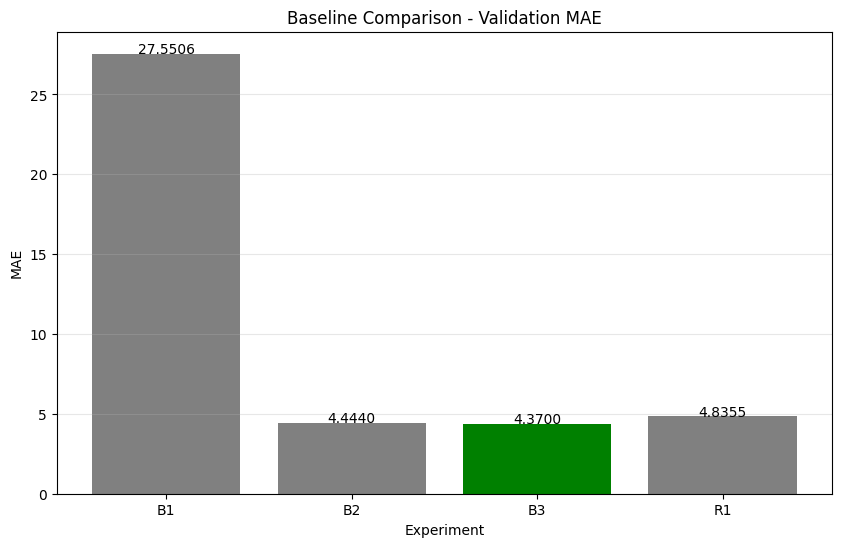

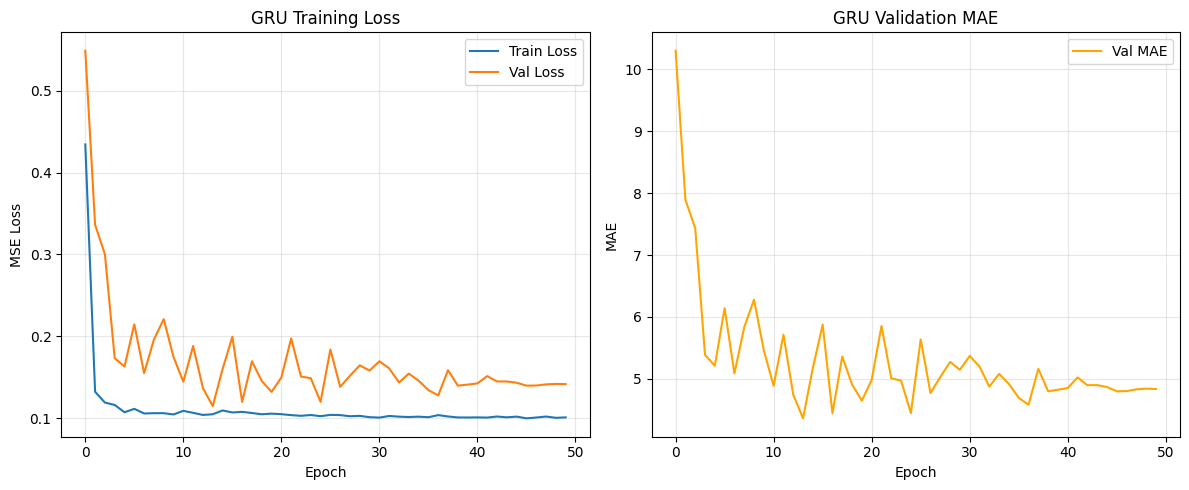

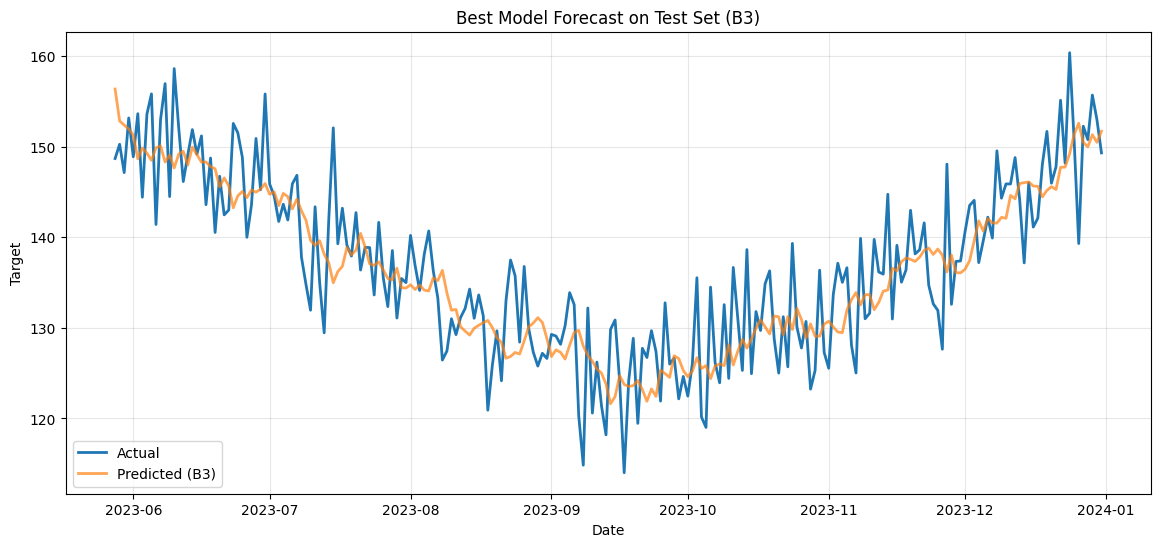


=== All artifacts saved successfully ===


In [14]:
# Сохранение runs.csv
df_results = pd.DataFrame(results_log)
df_results.to_csv(os.path.join(ARTIFACTS_DIR, "runs.csv"), index=False)

# График сравнения baseline
exp_ids = ['B1', 'B2', 'B3', 'R1']
exp_maes = [metrics_b1['mae'], metrics_b2['mae'], metrics_b3['mae'], metrics_r1_val['mae']]
colors = ['gray', 'gray', 'gray', 'green' if best_exp_id == 'R1' else 'gray']
colors[exp_ids.index(best_exp_id)] = 'green'

plt.figure(figsize=(10, 6))
plt.bar(exp_ids, exp_maes, color=colors)
plt.title('Baseline Comparison - Validation MAE')
plt.xlabel('Experiment')
plt.ylabel('MAE')
for i, v in enumerate(exp_maes):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
plt.grid(axis='y', alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, "baselines_compare.png"))
plt.show()

# Кривые обучения GRU
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('GRU Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['val_mae'], label='Val MAE', color='orange')
plt.title('GRU Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "gru_learning_curves.png"))
plt.show()

# График прогноза на test
plt.figure(figsize=(14, 6))

if best_exp_id == 'R1':
    # Для GRU используем последовательности
    test_dates = test_df['date'].iloc[WINDOW_SIZE:].reset_index(drop=True)
    plt.plot(test_dates[:len(test_targets)], test_targets[:len(test_dates)], label='Actual', linewidth=2)
    plt.plot(test_dates[:len(test_preds)], test_preds[:len(test_dates)], label='Predicted (GRU)', linewidth=2, alpha=0.7)
else:
    test_dates = test_df['date'].values
    plt.plot(test_dates, test_targets, label='Actual', linewidth=2)
    plt.plot(test_dates, test_preds, label=f'Predicted ({best_exp_id})', linewidth=2, alpha=0.7)

plt.title(f'Best Model Forecast on Test Set ({best_exp_id})')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, "best_forecast_test.png"))
plt.show()

print("\n=== All artifacts saved successfully ===")